In [ ]:
import json
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
DATA_DIR = Path("../../data/processed")

TRAIN_IMAGES = DATA_DIR / "train/images"
TRAIN_ANN = DATA_DIR / "train/annotations"

VAL_IMAGES = DATA_DIR / "validation/images"
VAL_ANN = DATA_DIR / "validation/annotations"

TEST_IMAGES = DATA_DIR / "test/images"

In [6]:
train_img_count = len(list(TRAIN_IMAGES.glob("*")))
train_ann_count = len(list(TRAIN_ANN.glob("*.json")))

val_img_count = len(list(VAL_IMAGES.glob("*")))
val_ann_count = len(list(VAL_ANN.glob("*.json")))

test_img_count = len(list(TEST_IMAGES.glob("*")))

df_counts = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [train_img_count, val_img_count, test_img_count],
    "Annotations": [train_ann_count, val_ann_count, 0]
})

df_counts


,Split,Images,Annotations
0,Train,191961,191961
1,Validation,32153,32153
2,Test,62629,0


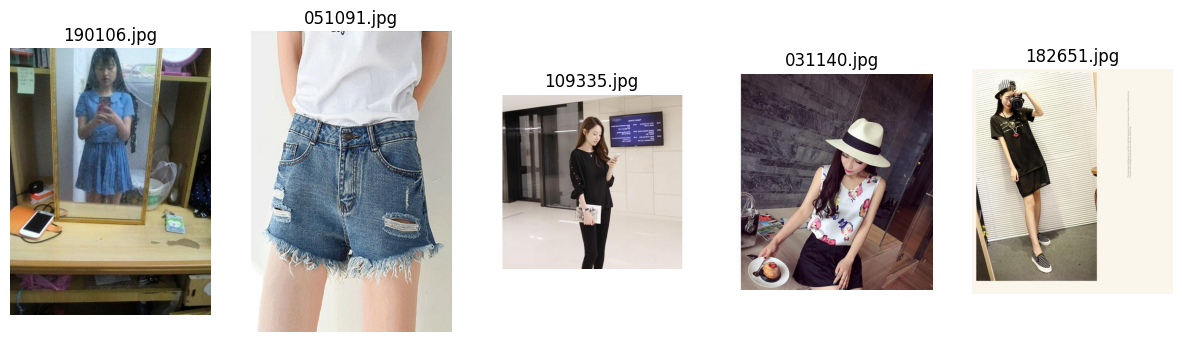

In [ ]:
def show_images(folder, n=5):
    images = list(folder.glob("*"))
    sample = random.sample(images, n)
    
    plt.figure(figsize=(15,5))
    
    for i, img_path in enumerate(sample):
        img = Image.open(img_path)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        
    plt.show()

show_images(TRAIN_IMAGES, 5)

In [8]:
sample_file = random.choice(list(TRAIN_ANN.glob("*.json")))

with open(sample_file) as f:
    data = json.load(f)

data


{'source': 'shop',
 'pair_id': 10741,
 'item1': {'segmentation': [[337.4,
    294.6,
    332.4,
    288.8,
    331.57,
    282.11,
    325.8,
    283.6,
    318.63,
    287.04,
    318.0,
    296.8,
    312.39,
    316.93,
    296.52,
    339.04,
    271.57,
    343.01,
    245.49,
    335.07,
    243.76,
    319.0,
    245.0,
    295.0,
    240.8,
    315.2,
    240.0,
    336.8,
    239.2,
    368.8,
    240.6,
    380.0,
    238.4,
    384.6,
    236.8,
    397.4,
    227.0,
    408.0,
    212.8,
    423.4,
    195.6,
    439.2,
    186.4,
    447.8,
    175.4,
    449.8,
    168.0,
    455.0,
    160.6,
    461.2,
    152.4,
    465.6,
    142.4,
    475.8,
    131.4,
    485.6,
    128.2,
    495.0,
    134.8,
    498.8,
    138.6,
    500.0,
    139.6,
    510.2,
    140.2,
    515.0,
    142.8,
    521.6,
    143.6,
    533.4,
    158.6,
    554.2,
    175.0,
    574.8,
    197.0,
    591.0,
    243.4,
    598.4,
    273.4,
    594.0,
    298.6,
    578.6,
    317.4,
    572.4,


In [13]:
records = []

ann_files = list(TRAIN_ANN.glob("*.json"))[:5000]

for file in ann_files:
    
    with open(file) as f:
        data = json.load(f)
    
    # loop through all keys (item1, item2, ...)
    for key, value in data.items():
        
        if key.startswith("item"):
            
            cat = value.get("category_id")
            
            if cat is not None:
                records.append(cat)


In [14]:
df = pd.DataFrame(records, columns=["category_id"])

df.head()

,category_id
0,7
1,1
2,9
3,4
4,9


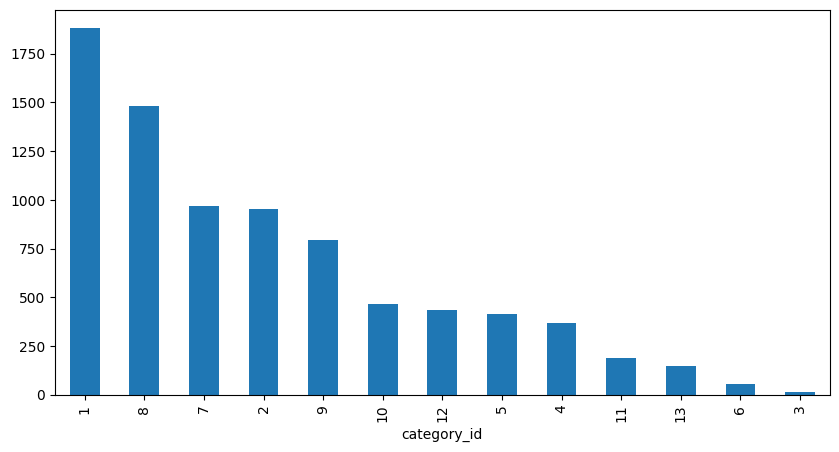

In [15]:
df["category_id"].value_counts().plot(kind="bar", figsize=(10,5))
plt.show()

In [ ]:
categories = {}

for f in list(TRAIN_ANN.glob("*.json"))[:500]:
    data = json.load(open(f))
    for key, value in data.items():
        if key.startswith("item"):
            cid = value.get("category_id")
            cname = value.get("category_name")
            if cid and cname:
                categories[cid] = cname

for cid in sorted(categories):
    print(cid, "-", categories[cid])

In [12]:
sizes = []

images = list(TRAIN_IMAGES.glob("*"))[:1000]

for img_path in images:
    try:
        img = Image.open(img_path)
        sizes.append(img.size)
    except:
        pass

df_sizes = pd.DataFrame(sizes, columns=["width", "height"])

df_sizes.describe()


,width,height
count,1000.000000,1000.000000
mean,599.387000,746.379000
std,148.237099,202.222589
min,100.000000,100.000000
25%,468.000000,624.000000
50%,640.000000,702.000000
75%,750.000000,900.000000
max,926.000000,1380.000000
